# L3a Advanced: Market-Impact Models

Trading cost is not summarized by one universal “impact” number. Different models answer different questions about order size, order-book events, and time. This notebook begins with the exact cost of walking a displayed book, then develops three reduced-form descriptions: linear signed-volume impact, order-flow imbalance, and transient impact with resilience.

The organizing question is:

> Which price response are we modeling, over what horizon, and relative to which benchmark?

Work through the companion order-book-mechanics notebook first; the code below uses the same price-time-priority engine.

> __Learning Objectives:__
>
> By the end of this notebook, we will be able to:
>
> * __Mechanical impact:__ Calculate the volume-weighted average price, depth slippage, midpoint change, and implementation shortfall of an order that walks a displayed book.
> * __Reduced-form models:__ Distinguish snapshot-dependent mechanical impact from a statistical impact model, and estimate linear signed-volume and order-flow-imbalance coefficients.
> * __Transient impact:__ Model impact that decays between trades and compare block and sliced execution costs with and without impact decay.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course environment and loads the `VLQuantitativeFinancePackage` matching engine, along with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and the `LinearAlgebra` and `Random` standard libraries. 

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Implementation
Next, we define helper functions that we use throughout the notebook. 

* The `impact_seed_book(...)` function builds a synthetic book with four bid and four ask levels, and the `mechanical_buy(...)` function resets that book, submits a market buy order, and returns a named tuple of execution measurements for that order. We also set shared plot styling defaults.

Let's define these helper functions:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

function impact_seed_book(; depth_scale::Int = 1)
    book = MyOrderBook(tick_size = 0.01)
    orders = [
        MyLimitOrder(1, Buy,  9_999, 100 * depth_scale),
        MyLimitOrder(2, Buy,  9_998, 150 * depth_scale),
        MyLimitOrder(3, Buy,  9_996, 250 * depth_scale),
        MyLimitOrder(4, Buy,  9_993, 300 * depth_scale),
        MyLimitOrder(5, Sell, 10_001,  80 * depth_scale),
        MyLimitOrder(6, Sell, 10_002, 120 * depth_scale),
        MyLimitOrder(7, Sell, 10_004, 200 * depth_scale),
        MyLimitOrder(8, Sell, 10_007, 300 * depth_scale),
    ]
    foreach(order -> submit_order!(book, order), orders)
    return book
end

function mechanical_buy(quantity::Int; depth_scale::Int = 1)
    book = impact_seed_book(; depth_scale = depth_scale)
    midpoint_before = midprice(book)
    best_ask_before = best_quotes(book).ask
    report = submit_order!(book, MyMarketOrder(Buy, quantity))
    @assert report.executed_quantity == quantity
    @assert validate_order_book(book)
    average_price = execution_vwap(report)
    return (
        order_quantity = quantity,
        vwap = average_price,
        depth_slippage_per_share = average_price - best_ask_before,
        implementation_shortfall = implementation_shortfall(report, midpoint_before),
        midpoint_after = midprice(book),
        midpoint_change = midprice(book) - midpoint_before,
        price_levels_consumed = length(unique(fill.price_ticks for fill in report.fills)),
    )
end

mechanical_buy (generic function with 1 method)

___

## Task 1: Measure what an order costs

In this task, we'll define the quantities that describe an execution, then compute them on a book we control completely. Getting the measurements right comes first, because a reported trading cost means nothing until we say which of these quantities it is.

### Measurement comes before modeling

The volume-weighted average price, the depth slippage per share, and the implementation shortfall each describe what an order cost, while the midpoint change describes how the quotes responded, so swapping one for another gives the wrong number.

Let $m_0$ and $a_0$ be the midpoint and best ask immediately before a buy order. For an executed quantity $Q$, the useful measurements are:

$$
\begin{aligned}
\operatorname{VWAP}(Q) &= \frac{1}{Q}\sum_j p_j f_j,\\
\text{depth slippage per share} &= \operatorname{VWAP}(Q)-a_0,\\
\text{implementation shortfall} &=Q\bigl(\operatorname{VWAP}(Q)-m_0\bigr),\\
\text{midpoint change} &=m_+-m_0.
\end{aligned}
$$

These quantities are not interchangeable. VWAP measures received execution prices; midpoint change measures the quoted book after execution; implementation shortfall includes the spread crossed by the trade.

___

### Mechanical impact: walk identical book snapshots

We reset the same book before every order and walk a range of order sizes through it.

Because the size is the only thing that varies, the resulting curve is deterministic: it is a transformation of the displayed ask schedule, not an empirical law.

Let's sweep a range of order sizes across identical snapshots:

In [3]:
order_sizes = [10, 40, 80, 100, 150, 200, 300, 400, 500, 600]
mechanical_results = DataFrame([mechanical_buy(quantity) for quantity in order_sizes])
mechanical_results

Row,order_quantity,vwap,depth_slippage_per_share,implementation_shortfall,midpoint_after,midpoint_change,price_levels_consumed
,Int64,Float64,Float64,Float64,Float64,Float64,Int64
1,10,100.01,0.0,0.1,100.0,0.0,1
2,40,100.01,0.0,0.4,100.0,0.0,1
3,80,100.01,0.0,0.8,100.005,0.005,1
4,100,100.012,0.002,1.2,100.005,0.005,2
5,150,100.015,0.00466667,2.2,100.005,0.005,2
6,200,100.016,0.006,3.2,100.015,0.015,2
7,300,100.024,0.014,7.2,100.015,0.015,3
8,400,100.028,0.018,11.2,100.03,0.03,3
9,500,100.036,0.0264,18.2,100.03,0.03,4


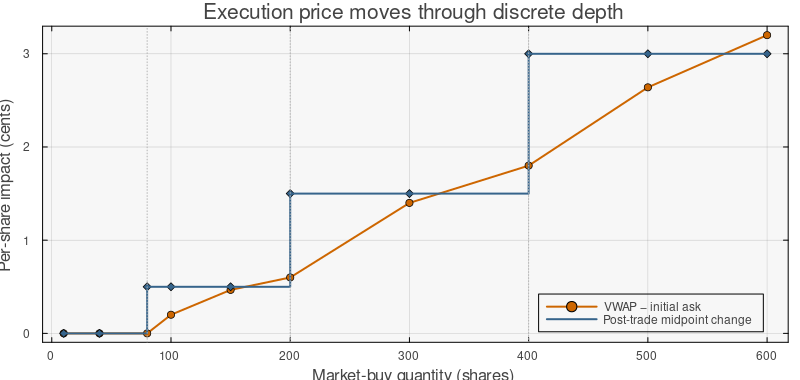

In [4]:
p1 = plot(
    mechanical_results.order_quantity,
    100 .* mechanical_results.depth_slippage_per_share;
    marker = :circle, color = :darkorange3, label = "VWAP − initial ask",
    xlabel = "Market-buy quantity (shares)", ylabel = "Per-share impact (cents)",
    title = "Execution price moves through discrete depth", size = (800, 380),
)
plot!(p1, mechanical_results.order_quantity,
    100 .* mechanical_results.midpoint_change;
    seriestype = :steppost, marker = :diamond, color = :steelblue4,
    label = "Post-trade midpoint change")
for boundary in (80, 200, 400)
    vline!(p1, [boundary]; color = :gray70, linewidth = 1, linestyle = :dot, label = "")
end
p1

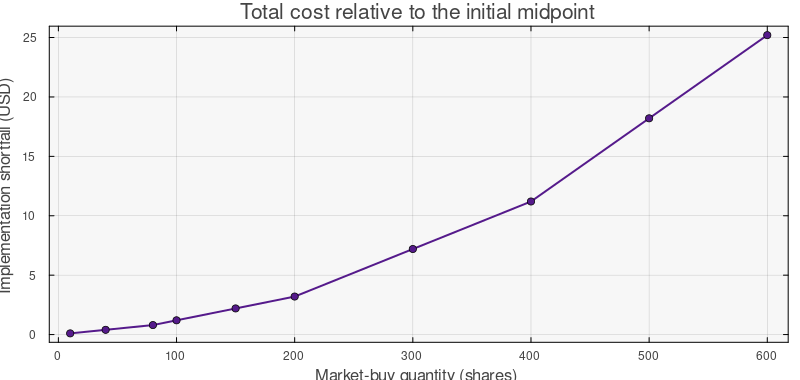

In [5]:
p2 = plot(
    mechanical_results.order_quantity,
    mechanical_results.implementation_shortfall;
    marker = :circle, color = :purple4, label = "",
    xlabel = "Market-buy quantity (shares)", ylabel = "Implementation shortfall (USD)",
    title = "Total cost relative to the initial midpoint", size = (800, 380),
)
p2

The midpoint-change curve is a staircase: it is flat while an order only partially consumes a price level, and it steps up when the order exhausts a level, at the 80-, 200-, and 400-share depth boundaries (the dotted lines in the first figure). The execution-price curve instead rises between those boundaries, because the shares beyond an exhausted level fill at the next, worse price and pull the volume-weighted average up. Implementation shortfall is piecewise linear: its slope is the current marginal price minus the initial midpoint, so it steepens at every depth boundary as larger orders pay worse marginal prices.

This experiment conditions on one displayed snapshot. It omits hidden liquidity, new limit orders, cancellations during execution, information, and strategic response. We should therefore call it **mechanical book-walking impact**, not a universal market-impact function.

### The same order has different impact in a different state

Impact is large relative to available depth, not simply because the share count is large. We compare the same 300-share order in the baseline book and in a book with three times as much quantity at every price.

In [6]:
state_comparison = DataFrame([
    merge((book_state = "Baseline depth",), mechanical_buy(300; depth_scale = 1)),
    merge((book_state = "Three-times depth",), mechanical_buy(300; depth_scale = 3)),
])
select(state_comparison, :book_state, :order_quantity, :vwap,
    :depth_slippage_per_share, :midpoint_change, :implementation_shortfall)

Row,book_state,order_quantity,vwap,depth_slippage_per_share,midpoint_change,implementation_shortfall
,String,Int64,Float64,Float64,Float64,Float64
1,Baseline depth,300,100.024,0.014,0.015,7.2
2,Three-times depth,300,100.012,0.002,0.005,3.6


The quantity is identical, but the deeper book absorbs it closer to the initial quote. This is why an impact coefficient must be interpreted together with liquidity and sampling horizon.

___

## Task 2: Fit reduced-form impact models

In this task, we'll leave the exact book behind and estimate two statistical models of price response, one driven by signed volume and one by quote events. Both are fit by least squares to simulated data, so we can compare what the estimator recovers against what we put in.

### Linear signed-volume impact

We simulate windows of signed trading volume and recover the impact coefficient $\lambda$ by least squares. This is the simplest model that links signed order flow to the size and direction of the price move.

A common reduced-form benchmark is:

$$
\Delta m_t=\lambda q_t+\varepsilon_t,
$$

where $q_t>0$ denotes buyer-initiated volume, $q_t<0$ denotes seller-initiated volume, and $\lambda$ has units of price change per signed share. In Kyle's equilibrium model, the related slope summarizes price sensitivity to order flow and market depth. Here we use the equation as a statistical benchmark and estimate it by least squares through the origin:

$$
\widehat\lambda=\frac{\sum_t q_t\Delta m_t}{\sum_t q_t^2}.
$$

Reference: Albert S. Kyle, [“Continuous Auctions and Insider Trading”](https://doi.org/10.2307/1913210), *Econometrica* 53(6), 1985.

Let's simulate signed-volume windows and recover the coefficient by least squares:

In [7]:
Random.seed!(5660)
number_of_windows = 400
signed_volume = rand(-500:500, number_of_windows)
lambda_true = 2.5e-5                         # USD per signed share
midpoint_noise = 0.004 .* randn(number_of_windows)
midpoint_change = lambda_true .* signed_volume .+ midpoint_noise
lambda_hat = dot(signed_volume, midpoint_change) / dot(signed_volume, signed_volume)

linear_fit_summary = DataFrame(
    parameter = ["True λ", "Estimated λ"],
    value_USD_per_signed_share = [lambda_true, lambda_hat],
)
linear_fit_summary

Row,parameter,value_USD_per_signed_share
,String,Float64
1,True λ,2.5e-5
2,Estimated λ,2.44374e-5


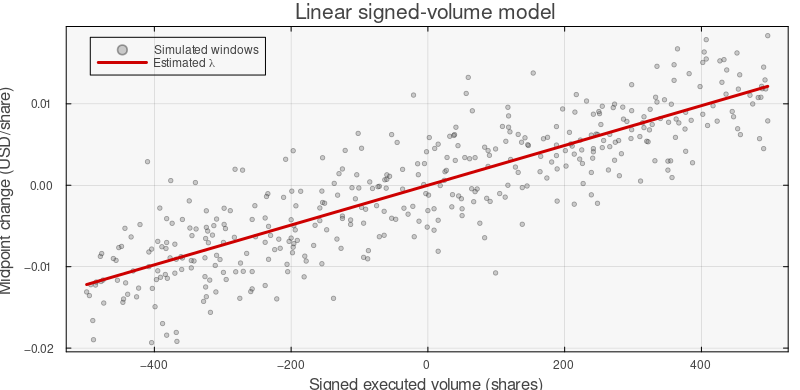

In [8]:
volume_grid = range(extrema(signed_volume)...; length = 200)
scatter(
    signed_volume, midpoint_change;
    markersize = 2.5, markeralpha = 0.35, color = :gray45, label = "Simulated windows",
    xlabel = "Signed executed volume (shares)", ylabel = "Midpoint change (USD/share)",
    title = "Linear signed-volume model", size = (800, 390),
)
plot!(volume_grid, lambda_hat .* volume_grid;
    color = :red3, linewidth = 3, label = "Estimated λ")

The fitted line averages across many event windows. Unlike the staircase produced by a single book snapshot, it is a reduced-form conditional expectation. Its slope depends on how trades are signed, the time interval used to aggregate them, and the liquidity regime represented in the data.

___

### Order-flow imbalance includes non-trade events

Next, we sign a stream of quote events (new limit orders, cancellations, and executions), add them up over short windows, and regress the midpoint change on that sum.

Short-horizon prices respond to changes in supply and demand at the quotes, not only to completed trades. A simple best-quote order-flow-imbalance convention assigns

- positive contribution to quantity added at the bid or removed from the ask;
- negative contribution to quantity removed from the bid or added at the ask.

Thus, limit orders and cancellations enter the same state-change measure as executions. The contributions use only quantity changes at the standing quote prices (the full Cont–Kukanov–Stoikov measure also accounts for changes in the quote prices themselves), and the midpoint change is measured as the response over each window. Over window $k$:

$$
\operatorname{OFI}_k=\sum_{n\in k}e_n,
\qquad
\Delta m_k=\beta\operatorname{OFI}_k+\epsilon_k.
$$

Reference: Rama Cont, Arseniy Kukanov, and Sasha Stoikov, [“The Price Impact of Order Book Events”](https://doi.org/10.1093/jjfinec/nbt003), *Journal of Financial Econometrics* 12(1), 2014.

First, we record a synthetic stream of best-quote events (additions and removals on each side of the book) and sign each one using the convention above. The `event_type` column records whether a change came from a new limit order, a cancellation, or an execution against the quote; the signing convention uses only the book side and the direction of the change. We store the event stream in the `events::DataFrame` variable:

In [9]:
function signed_ofi_event(side::String, action::String, quantity::Int)
    if (side == "bid" && action == "add") || (side == "ask" && action == "remove")
        return quantity
    end
    return -quantity
end

events = let
    table = DataFrame(
        window = repeat(1:6, inner = 4),
        book_side = repeat(["bid", "ask", "bid", "ask"], 6),
        action = repeat(["add", "add", "remove", "remove"], 6),
        event_type = repeat(["limit order", "limit order", "cancellation", "cancellation",
                             "limit order", "limit order", "execution", "execution"], 3),
        quantity = [80, 35, 20, 60, 45, 90, 70, 15, 110, 20, 30, 85,
                    30, 75, 95, 25, 70, 45, 10, 100, 40, 105, 55, 35],
    )
    table.ofi_contribution = [
        signed_ofi_event(row.book_side, row.action, row.quantity) for row in eachrow(table)
    ]
    table
end

Row,window,book_side,action,event_type,quantity,ofi_contribution
,Int64,String,String,String,Int64,Int64
1,1,bid,add,limit order,80,80
2,1,ask,add,limit order,35,-35
3,1,bid,remove,cancellation,20,-20
4,1,ask,remove,cancellation,60,60
5,2,bid,add,limit order,45,45
6,2,ask,add,limit order,90,-90
7,2,bid,remove,execution,70,-70
8,2,ask,remove,execution,15,15
9,3,bid,add,limit order,110,110


So what does the event stream imply for prices? We aggregate the signed contributions within each window and attach a simulated midpoint change, storing the result in the `ofi_windows::DataFrame` variable:

In [10]:
beta_true = 4.0e-5; # USD per share of imbalance
ofi_windows = let
    windows = combine(groupby(events, :window; sort = true), :ofi_contribution => sum => :ofi)
    windows.midpoint_change = beta_true .* windows.ofi .+
        [0.0005, -0.0003, 0.0002, -0.0004, 0.0001, -0.0002]
    windows
end

Row,window,ofi,midpoint_change
,Int64,Int64,Float64
1,1,85,0.0039
2,2,-100,-0.0043
3,3,145,0.006
4,4,-115,-0.005
5,5,115,0.0047
6,6,-85,-0.0036


Finally, we estimate the imbalance coefficient by least squares through the origin. Do we recover a value close to the coefficient used to generate the data?

In [11]:
beta_hat = dot(ofi_windows.ofi, ofi_windows.midpoint_change) /
    dot(ofi_windows.ofi, ofi_windows.ofi)

4.244699339589851e-5

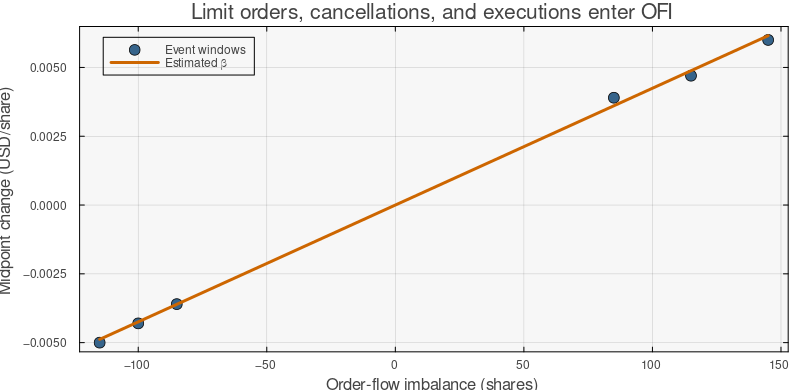

In [12]:
ofi_grid = range(extrema(ofi_windows.ofi)...; length = 100)
scatter(
    ofi_windows.ofi, ofi_windows.midpoint_change;
    marker = :circle, markersize = 6, color = :steelblue4, label = "Event windows",
    xlabel = "Order-flow imbalance (shares)", ylabel = "Midpoint change (USD/share)",
    title = "Limit orders, cancellations, and executions enter OFI", size = (800, 390),
)
plot!(ofi_grid, beta_hat .* ofi_grid;
    color = :darkorange3, linewidth = 3, label = "Estimated β")

OFI is closer to the book's event mechanics than trade volume alone. An ask cancellation and an aggressive buy both remove displayed ask quantity, so both contribute positive pressure under this convention. The model remains an empirical window-level relationship; it is not a claim that every event causes the fitted price change in isolation.

___

## Task 3: Model impact that decays between trades

In this task, we'll run one block order and a five-slice schedule through an impact model whose effect decays between trades. Splitting an order only helps if the book refills, so the fraction $\rho$ that survives between trades decides which schedule costs less.

### Transient impact and resilience

A static book cannot explain what happens while an order is split over time. Introduce an impact state $x_k$ and trading quantity $u_k$:

$$
x_{k+1}=\rho\bigl(x_k+\eta u_k\bigr),
\qquad 0\leq\rho\leq1.
$$

The trade moves impact from $x_k$ to $x_k+\eta u_k$; the average execution impact during that trade is $x_k+\tfrac12\eta u_k$. Between decisions, only the fraction $\rho$ remains. Small $\rho$ represents fast resilience; $\rho=1$ represents no decay.

This abstraction follows the central insight of Obizhaeva and Wang: execution depends on dynamic liquidity replenishment, not only static spread and depth. See [“Optimal Trading Strategy and Supply/Demand Dynamics”](https://doi.org/10.1016/j.finmar.2012.09.001), *Journal of Financial Markets* 16(1), 2013.

Let's trace a block schedule and a five-slice schedule through this recursion:

In [13]:
function transient_execution(schedule::Vector{Int}; rho::Float64, eta::Float64)
    impact_before = 0.0
    rows = NamedTuple[]
    total_cost = 0.0
    for (step, quantity) in enumerate(schedule)
        average_execution_impact = impact_before + 0.5 * eta * quantity
        total_cost += quantity * average_execution_impact
        impact_after_trade = impact_before + eta * quantity
        impact_after_decay = rho * impact_after_trade
        push!(rows, (
            step = step,
            quantity = quantity,
            impact_before = impact_before,
            average_execution_impact = average_execution_impact,
            impact_after_trade = impact_after_trade,
            impact_after_decay = impact_after_decay,
        ))
        impact_before = impact_after_decay
    end
    return (path = DataFrame(rows), total_cost = total_cost)
end

total_quantity = 450
block_schedule = [450, 0, 0, 0, 0]
sliced_schedule = fill(90, 5)
@assert sum(block_schedule) == total_quantity
@assert sum(sliced_schedule) == total_quantity
eta = 5.0e-5

no_decay_block = transient_execution(block_schedule; rho = 1.0, eta = eta)
no_decay_sliced = transient_execution(sliced_schedule; rho = 1.0, eta = eta)
resilient_block = transient_execution(block_schedule; rho = 0.55, eta = eta)
resilient_sliced = transient_execution(sliced_schedule; rho = 0.55, eta = eta)

cost_comparison = DataFrame(
    liquidity_dynamics = ["No decay", "No decay", "Resilient", "Resilient"],
    schedule = ["Block", "Five slices", "Block", "Five slices"],
    total_quantity = fill(total_quantity, 4),
    impact_cost = [no_decay_block.total_cost, no_decay_sliced.total_cost,
        resilient_block.total_cost, resilient_sliced.total_cost],
)
cost_comparison

Row,liquidity_dynamics,schedule,total_quantity,impact_cost
,String,String,Int64,Float64
1,No decay,Block,450,5.0625
2,No decay,Five slices,450,5.0625
3,Resilient,Block,450,5.0625
4,Resilient,Five slices,450,2.44286


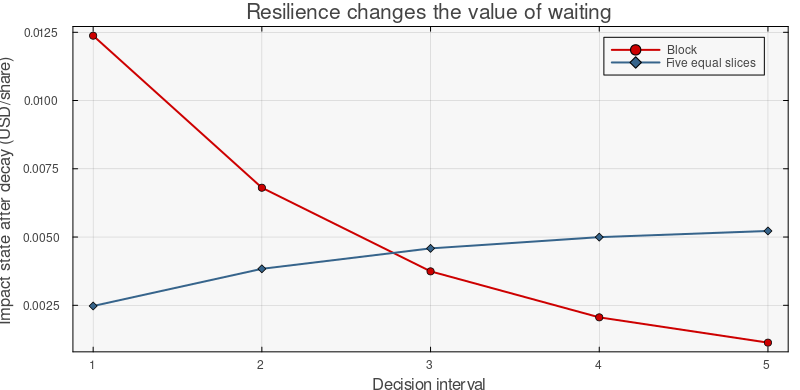

In [14]:
plot(
    resilient_block.path.step, resilient_block.path.impact_after_decay;
    marker = :circle, color = :red3, label = "Block",
    xlabel = "Decision interval", ylabel = "Impact state after decay (USD/share)",
    title = "Resilience changes the value of waiting", size = (800, 390),
    xticks = 1:5,
)
plot!(resilient_sliced.path.step, resilient_sliced.path.impact_after_decay;
    marker = :diamond, color = :steelblue4, label = "Five equal slices")

When $\rho=1$, splitting does not reduce total mechanical impact cost: the later slices inherit all impact created by the earlier ones. When $\rho<1$, impact partially decays between slices, so waiting can reduce modeled cost.

This is not yet an optimal-execution result. Waiting also exposes the unexecuted position to price risk, and a complete optimization must specify that risk, the deadline, and the admissible schedules. The current experiment isolates the role of resilience.

___

## Model map

| Description | Input | Output | Appropriate interpretation |
|:--|:--|:--|:--|
| Displayed-book walk | One book snapshot and order size | VWAP, depth slippage, midpoint change, shortfall | Immediate mechanical execution cost |
| Linear signed volume | Signed executed volume over a window | Conditional midpoint change | Reduced-form average price sensitivity |
| Order-flow imbalance | Limit additions, cancellations, and executions | Short-window midpoint change | Net pressure at the quoted book |
| Transient impact | Trade schedule and resilience parameters | Impact path and schedule cost | Dynamic cost when liquidity recovers |

The models are complementary rather than interchangeable. A book walk is exact conditional on its snapshot but silent about recovery. A regression describes average data behavior but suppresses queue detail. A transient model supplies dynamics but requires assumptions about resilience.

___

## Summary

Market impact is a family of measurements and models whose meaning depends on the book state, event aggregation, and time horizon.

> __Key Takeaways:__
>
> * **Mechanical impact is state dependent:** Resetting the same book reveals a discrete depth curve, while changing book depth changes the cost of the same order.
> * **Order flow is broader than trade volume:** Limit orders and cancellations alter supply and demand and belong in short-horizon imbalance measures.
> * **Slicing requires resilience to help:** Splitting is cost-equivalent in the no-decay transient-impact model; its benefit arises only when impact decays or liquidity returns between trades.

A credible execution study must therefore name its benchmark, horizon, event convention, and liquidity dynamics before interpreting an impact coefficient.

___